In [1]:
import sys
print("Python version:", sys.version)

Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
1
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

In [4]:
np.random.seed(42) #Ensures reproducible experiments, which is critical for scientific evaluation.

In [5]:
df = pd.read_csv("../data/census.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df.columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
    "income"
]

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df = df[
    ["age", "workclass", "education", "occupation", "sex", "hours-per-week", "income"]
]
df.head()

#Reduces dimensionality Focuses on interpretable features Keeps project clean and explainable

,age,workclass,education,occupation,sex,hours-per-week,income
0,39,State-gov,Bachelors,Adm-clerical,Male,40,<=50K
1,50,Self-emp-not-inc,Bachelors,Exec-managerial,Male,13,<=50K
2,38,Private,HS-grad,Handlers-cleaners,Male,40,<=50K
3,53,Private,11th,Handlers-cleaners,Male,40,<=50K
4,28,Private,Bachelors,Prof-specialty,Female,40,<=50K


In [8]:
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col) #Without this, models silently break later

In [9]:
df.replace("?", np.nan, inplace=True)
df.isnull().sum()

age                  0
workclass         1836
education            0
occupation        1843
sex                  0
hours-per-week       0
income               0
dtype: int64

In [10]:
df.dropna(inplace=True)
df.shape

(30718, 7)

In [11]:
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})
df["income"].value_counts()

income
0    23068
1     7650
Name: count, dtype: int64

In [12]:
df.head()

,age,workclass,education,occupation,sex,hours-per-week,income
0,39,State-gov,Bachelors,Adm-clerical,Male,40,0
1,50,Self-emp-not-inc,Bachelors,Exec-managerial,Male,13,0
2,38,Private,HS-grad,Handlers-cleaners,Male,40,0
3,53,Private,11th,Handlers-cleaners,Male,40,0
4,28,Private,Bachelors,Prof-specialty,Female,40,0


In [13]:
print("Dataset shape:", df.shape)
df.dtypes

Dataset shape: (30718, 7)


age                int64
workclass         object
education         object
occupation        object
sex               object
hours-per-week     int64
income             int64
dtype: object

In [14]:
df['income'].value_counts(normalize=True)

income
0    0.75096
1    0.24904
Name: proportion, dtype: float64

In [15]:
df[['age', 'hours-per-week']].describe()

,age,hours-per-week
count,30718.000000,30718.000000
mean,38.443584,40.949313
std,13.118227,11.985382
min,17.000000,1.000000
25%,28.000000,40.000000
50%,37.000000,40.000000
75%,47.000000,45.000000
max,90.000000,99.000000


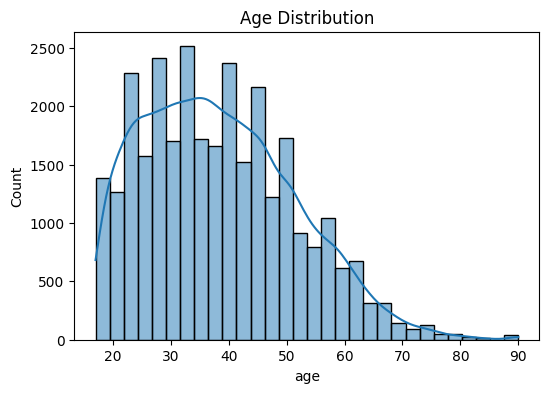

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.savefig("Age Distribution.png")
plt.show()

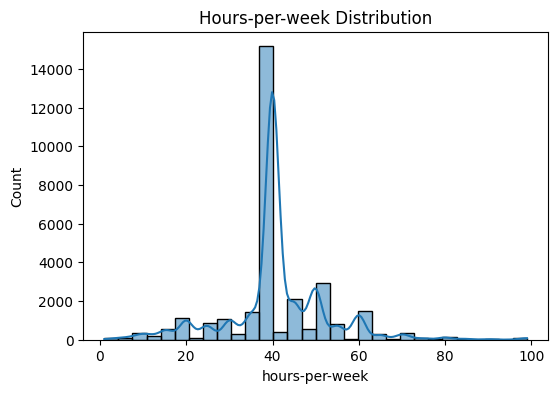

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['hours-per-week'], bins=30, kde=True)
plt.title("Hours-per-week Distribution")
plt.savefig("Hours-per-week Distribution.png")
plt.show()

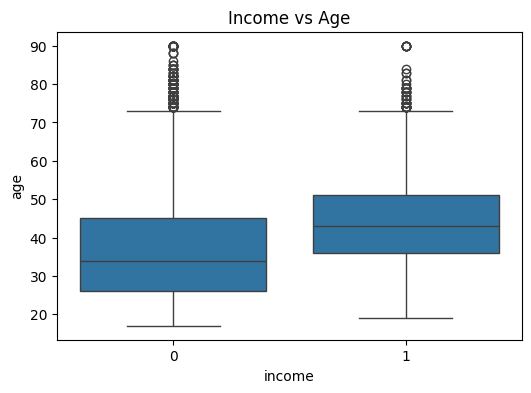

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='age', data=df)
plt.title("Income vs Age")
plt.savefig("Income vs Age.png")
plt.show()

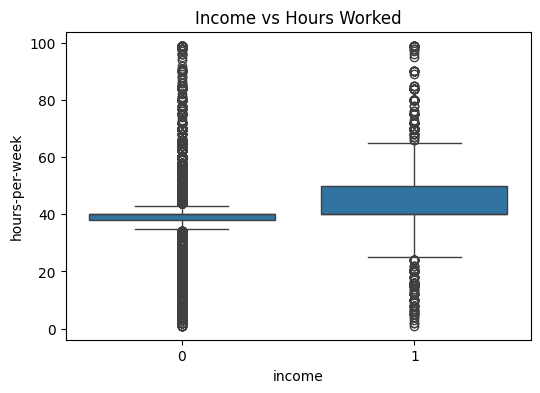

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title("Income vs Hours Worked")
plt.savefig("Income vs Hours Worked.png")
plt.show()

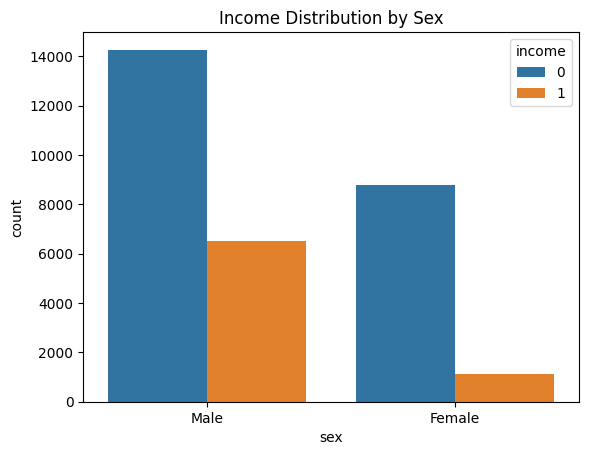

In [20]:
sns.countplot(x='sex', hue='income', data=df)
plt.title("Income Distribution by Sex")
plt.savefig("Income Distribution by Sex.png")
plt.show()


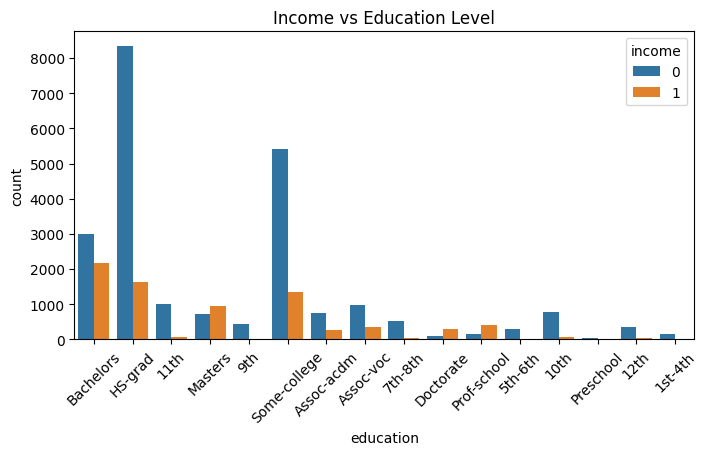

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Income vs Education Level")
plt.savefig("Income vs Education Level.png")
plt.show()

In [22]:
df[['age', 'hours-per-week', 'income']].corr()

,age,hours-per-week,income
age,1.000000,0.101879,0.242431
hours-per-week,0.101879,1.000000,0.228547
income,0.242431,0.228547,1.000000


In [23]:
X = df.drop("income", axis=1)
y = df["income"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30718, 6)
y shape: (30718,)


In [24]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features, numerical_features


(['workclass', 'education', 'occupation', 'sex'], ['age', 'hours-per-week'])

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((24574, 6), (6144, 6))

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [27]:
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_reg_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
log_reg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression Performance
Accuracy: 0.80615234375
F1 Score: 0.5279429250891795
ROC AUC: 0.8314435888500755


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest Performance
Accuracy: 0.7766927083333334
F1 Score: 0.5106990014265336
ROC AUC: 0.7954106003042744


In [33]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)


array([[4056,  558],
       [ 814,  716]])

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      4614
           1       0.56      0.47      0.51      1530

    accuracy                           0.78      6144
   macro avg       0.70      0.67      0.68      6144
weighted avg       0.77      0.78      0.77      6144

